# Exp. 5 — Grieta en Zigzag: Multi-Splat sobre Defecto Elongado No-Gaussiano

## Objetivos
1. Modelar una **grieta en zigzag** sobre la misma superficie cilíndrica (R=52 mm).
2. Estudiar el **fallo del splat único (K=1)** al intentar ajustar un defecto elongado.
3. Demostrar cómo el **Multi-Splat** (K=1..7, inicialización greedy por residuo) converge al volumen real.
4. Analizar el número óptimo de splats K* en función del error de volumen y coste excedente.

## Modelo de grieta
La grieta se define como un **surco Gaussiano** (sección transversal) que sigue una polilínea en zigzag:
$$Z_{\text{grieta}}(x,y) = -D \cdot \exp\!\left(-\frac{d_{\min}(x,y)^2}{2\,\sigma_w^2}\right)$$
donde $d_{\min}$ es la distancia mínima de cada punto a la polilínea y $\sigma_w$ es la semi-anchura de la grieta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.optimize import least_squares as _lsq, minimize_scalar
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pandas as pd
import time

## 1. Escena cilíndrica + Grieta en Zigzag

In [2]:
# ── Parámetros físicos (idénticos a Exp. 3 y 4) ──────────────────────────────
R      = 52.0   # mm radio del cilindro
FOV_X  = 120.0  # mm
FOV_Y  = 100.0  # mm
N_ROWS = 512
N_COLS = 614

dx = FOV_X / N_COLS
dy = FOV_Y / N_ROWS

x_vec = np.linspace(-FOV_X/2, FOV_X/2, N_COLS)
y_vec = np.linspace(-FOV_Y/2, FOV_Y/2, N_ROWS)
X_img, Y_img = np.meshgrid(x_vec, y_vec)

mask_valid  = np.abs(X_img) < R
Z_nominal   = np.where(mask_valid, np.sqrt(np.maximum(R**2 - X_img**2, 0)), 0.0)

# ── Parámetros de la grieta ───────────────────────────────────────────────────
CRACK_DEPTH  = 1.5   # mm profundidad máxima (amplitud)
CRACK_SIGMA  = 2.0   # mm semi-anchura (σ sección transversal Gaussiana)
N_SEGS       = 4     # número de segmentos del zigzag
SEG_L        = 12.0  # mm longitud de cada segmento
ZZ_ANGLE_DEG = 40.0  # grados (ángulo de cada segmento respecto a la horizontal)

# Vértices del zigzag
verts = np.zeros((N_SEGS + 1, 2))
for i in range(N_SEGS):
    a_rad = np.radians(ZZ_ANGLE_DEG if i % 2 == 0 else -ZZ_ANGLE_DEG)
    verts[i+1] = verts[i] + SEG_L * np.array([np.cos(a_rad), np.sin(a_rad)])

# Centrar la polilínea en (0, 0)
verts -= verts.mean(axis=0)

# ── Distancia mínima de cada pixel a la polilínea (vectorizado) ───────────────
def min_dist_to_polyline(Xg, Yg, pts):
    """Distancia mínima de cada punto (Xg,Yg) a la polilínea definida por 'pts'."""
    min_d = np.full_like(Xg, np.inf, dtype=float)
    for i in range(len(pts) - 1):
        a, b = pts[i], pts[i+1]
        ab = b - a
        ab_len2 = float(np.dot(ab, ab))
        t = ((Xg - a[0]) * ab[0] + (Yg - a[1]) * ab[1]) / ab_len2
        t = np.clip(t, 0.0, 1.0)
        d = np.sqrt((Xg - (a[0] + t * ab[0]))**2 + (Yg - (a[1] + t * ab[1]))**2)
        np.minimum(min_d, d, out=min_d)
    return min_d

d_min   = min_dist_to_polyline(X_img, Y_img, verts)
defect  = -CRACK_DEPTH * np.exp(-0.5 * (d_min / CRACK_SIGMA)**2)  # negativo: surco
Z_img   = Z_nominal + defect   # superficie completa con grieta

# Máscaras
SEG_THRESHOLD = 0.05
mask_defect   = (-defect) > (SEG_THRESHOLD * CRACK_DEPTH)

# Volumen de la grieta (material perdido) = integral de |defecto|
V_gt = float(np.sum(-defect * mask_valid) * dx * dy)

# Aproximación analítica: V ≈ N_segs × L_seg × sqrt(2π) × σ × D
# (ignora solapamientos en vértices)
V_analytical = N_SEGS * SEG_L * np.sqrt(2*np.pi) * CRACK_SIGMA * CRACK_DEPTH

print(f"Resolución: dx={dx:.4f} mm/px, dy={dy:.4f} mm/px")
print(f"Grieta: D={CRACK_DEPTH} mm, σ={CRACK_SIGMA} mm, {N_SEGS} segmentos de {SEG_L} mm")
print(f"Volumen GT (numérico):    V = {V_gt:.4f} mm³")
print(f"Volumen analítico aprox.: V = {V_analytical:.4f} mm³")
print(f"Pixels con grieta:        {mask_defect.sum()} px  ({mask_defect.sum()*dx*dy:.1f} mm²)")
print(f"Vértices zigzag (mm):\n{verts}")

Resolución: dx=0.1954 mm/px, dy=0.1953 mm/px
Grieta: D=1.5 mm, σ=2.0 mm, 4 segmentos de 12.0 mm
Volumen GT (numérico):    V = 392.1821 mm³
Volumen analítico aprox.: V = 360.9545 mm³
Pixels con grieta:        13976 px  (533.5 mm²)
Vértices zigzag (mm):
[[-18.38506663  -3.08538053]
 [ -9.19253332   4.62807079]
 [  0.          -3.08538053]
 [  9.19253332   4.62807079]
 [ 18.38506663  -3.08538053]]


## 2. Visualización de la grieta

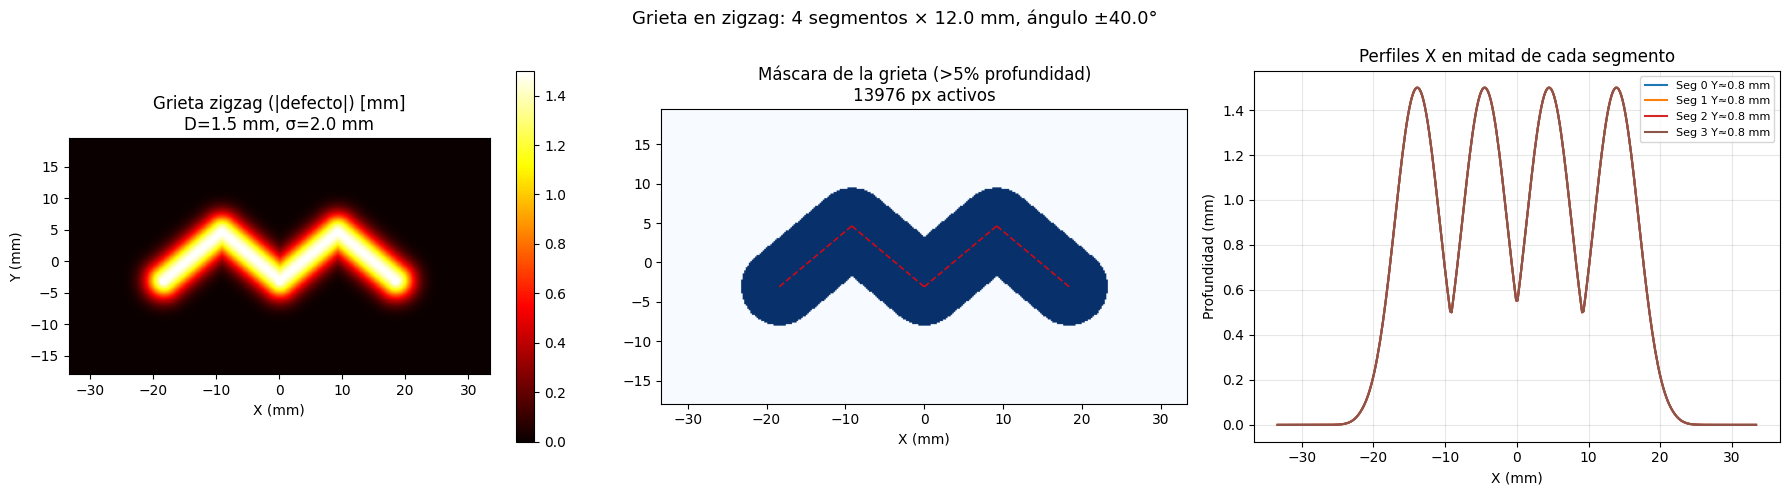

In [3]:
# ROI amplia que cubre toda la grieta
pad_mm = 15.0
xv0 = verts[:, 0].min() - pad_mm
xv1 = verts[:, 0].max() + pad_mm
yv0 = verts[:, 1].min() - pad_mm
yv1 = verts[:, 1].max() + pad_mm
jx0 = max(int(np.searchsorted(x_vec, xv0)), 0)
jx1 = min(int(np.searchsorted(x_vec, xv1)), N_COLS)
jy0 = max(int(np.searchsorted(y_vec, yv0)), 0)
jy1 = min(int(np.searchsorted(y_vec, yv1)), N_ROWS)
ext = [x_vec[jx0], x_vec[jx1-1], y_vec[jy0], y_vec[jy1-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mapa de defecto (profundidad del surco)
vd = CRACK_DEPTH
im0 = axes[0].imshow(-defect[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                     cmap='hot', vmin=0, vmax=vd)
for i in range(len(verts)-1):
    axes[0].plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]],
                 'w--', lw=1.2, alpha=0.7)
axes[0].plot(*verts.T, 'wo', ms=4)
axes[0].set_title(f'Grieta zigzag (|defecto|) [mm]\nD={CRACK_DEPTH} mm, σ={CRACK_SIGMA} mm')
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')
plt.colorbar(im0, ax=axes[0])

# Máscara
axes[1].imshow(mask_defect[jy0:jy1, jx0:jx1].astype(float), origin='lower', extent=ext,
               cmap='Blues', vmin=0, vmax=1)
for i in range(len(verts)-1):
    axes[1].plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]],
                 'r--', lw=1.2, alpha=0.8)
axes[1].set_title(f'Máscara de la grieta (>{SEG_THRESHOLD*100:.0f}% profundidad)\n{mask_defect.sum()} px activos')
axes[1].set_xlabel('X (mm)')

# Perfiles transversales en distintos puntos de la grieta
mid_seg_x = [(verts[i,0]+verts[i+1,0])/2 for i in range(N_SEGS)]
mid_seg_y = [(verts[i,1]+verts[i+1,1])/2 for i in range(N_SEGS)]
colors_seg = plt.cm.tab10(np.linspace(0, 0.5, N_SEGS))
for k, (mx, my, col) in enumerate(zip(mid_seg_x, mid_seg_y, colors_seg)):
    row_mid = int(np.argmin(np.abs(y_vec - my)))
    axes[2].plot(x_vec[jx0:jx1], -defect[row_mid, jx0:jx1], color=col,
                 lw=1.5, label=f'Seg {k} Y≈{my:.1f} mm')
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Profundidad (mm)')
axes[2].set_title('Perfiles X en mitad de cada segmento')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(f'Grieta en zigzag: {N_SEGS} segmentos × {SEG_L} mm, ángulo ±{ZZ_ANGLE_DEG}°', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Funciones SG y estimación nominal sin CAD

In [4]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx * y_idx,
        x_idx, y_idx, np.ones_like(x_idx)
    ], axis=-1)
    A_mat = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack(
        [cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT) for k in kernels],
        axis=-1
    )

def coeffs_to_physical(coeffs_px, dx_, dy_):
    return np.stack([
        coeffs_px[..., 0] / dx_**2,
        coeffs_px[..., 1] / dy_**2,
        coeffs_px[..., 2] / (dx_ * dy_),
        coeffs_px[..., 3] / dx_,
        coeffs_px[..., 4] / dy_,
        coeffs_px[..., 5]
    ], axis=-1)

# ── Estimación nominal sin CAD (sensing ring alrededor de la grieta) ──────────
RING_WIDTH_MM = 15.0
ring_w_px = int(round(RING_WIDTH_MM / min(dx, dy))) | 1
kernel_ring = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ring_w_px, ring_w_px))
mask_dilated_r = cv2.dilate(mask_defect.astype(np.uint8), kernel_ring).astype(bool)
mask_ring = mask_dilated_r & ~mask_defect & mask_valid

WIN_TOPO_PX = int(round(15.0 / min(dx, dy))) | 1
coeffs_topo_px = sg2d_jacobian_projection_cv2(Z_img, window_size=WIN_TOPO_PX)
coeffs_topo_ph = coeffs_to_physical(coeffs_topo_px, dx, dy)

kappa1_ring = 2 * coeffs_topo_ph[mask_ring, 0]
med_k1 = np.median(np.abs(kappa1_ring))
med_k2 = np.median(np.abs(2 * coeffs_topo_ph[mask_ring, 1]))

x_ring_pts = X_img[mask_ring]
z_ring_pts = Z_img[mask_ring]
R_init = float(np.sqrt(np.mean(z_ring_pts**2 + x_ring_pts**2)))
res_R = minimize_scalar(
    lambda Rv: np.sum((z_ring_pts - np.sqrt(np.maximum(Rv**2 - x_ring_pts**2, 0)))**2),
    bounds=(R_init*0.7, R_init*1.3), method='bounded'
)
R_est = float(res_R.x)
Z_nominal_est = np.where(mask_valid, np.sqrt(np.maximum(R_est**2 - X_img**2, 0)), 0.0)

print(f"R_est = {R_est:.4f} mm  (GT R = {R:.4f} mm, error = {abs(R_est-R)*1e3:.1f} µm)")

R_est = 51.9942 mm  (GT R = 52.0000 mm, error = 5.8 µm)


## 4. Ruido + mapa diferencial

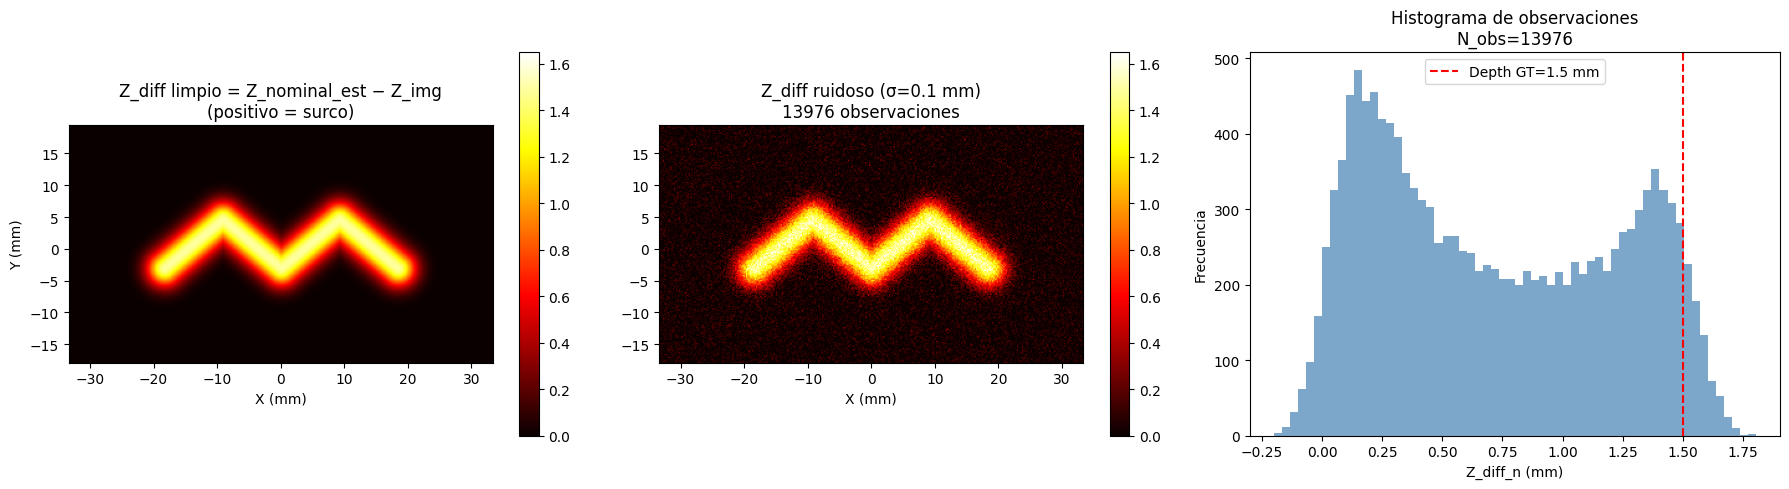

N_obs=13976, max(z_obs)=1.804 mm, SNR≈18.0


In [5]:
SIGMA_NOISE = 0.1   # mm
RNG_SEED    = 42
rng = np.random.default_rng(RNG_SEED)
noise = rng.normal(0.0, SIGMA_NOISE, size=Z_img.shape)

Z_img_n  = Z_img + noise                  # imagen ruidosa
Z_diff   = Z_nominal_est - Z_img          # diferencial limpio
Z_diff_n = Z_nominal_est - Z_img_n        # diferencial ruidoso

# Observaciones dentro de la máscara (solo pixels con grieta)
rows_m, cols_m = np.where(mask_defect & mask_valid)
x_obs = X_img[rows_m, cols_m]
y_obs = Y_img[rows_m, cols_m]
z_obs = Z_diff_n[rows_m, cols_m]   # queremos ajustar el valor positivo del surco
N_obs = len(x_obs)

# Visualización del diferencial
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmax_d = CRACK_DEPTH * 1.1

im0 = axes[0].imshow(Z_diff[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                     cmap='hot', vmin=0, vmax=vmax_d)
axes[0].set_title('Z_diff limpio = Z_nominal_est − Z_img\n(positivo = surco)'); plt.colorbar(im0, ax=axes[0])
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')

im1 = axes[1].imshow(Z_diff_n[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                     cmap='hot', vmin=0, vmax=vmax_d)
axes[1].set_title(f'Z_diff ruidoso (σ={SIGMA_NOISE} mm)\n{N_obs} observaciones'); plt.colorbar(im1, ax=axes[1])
axes[1].set_xlabel('X (mm)')

axes[2].hist(z_obs, bins=60, color='steelblue', edgecolor='none', alpha=0.7)
axes[2].axvline(CRACK_DEPTH, color='r', ls='--', label=f'Depth GT={CRACK_DEPTH} mm')
axes[2].set_xlabel('Z_diff_n (mm)'); axes[2].set_ylabel('Frecuencia')
axes[2].set_title(f'Histograma de observaciones\nN_obs={N_obs}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"N_obs={N_obs}, max(z_obs)={z_obs.max():.3f} mm, SNR≈{z_obs.max()/SIGMA_NOISE:.1f}")

## 5. Funciones Multi-Splat (Jacobiano analítico + subsampling)

In [6]:
def gauss2d_rotated(params, x, y):
    A, x0, y0, sx, sy, th = params
    cos_t, sin_t = np.cos(th), np.sin(th)
    u = (x - x0)*cos_t + (y - y0)*sin_t
    v = -(x - x0)*sin_t + (y - y0)*cos_t
    return A * np.exp(-0.5*(u**2/sx**2 + v**2/sy**2))

def gauss_mixture(params, x, y, K):
    result = np.zeros(len(x) if x.ndim == 1 else x.size, dtype=float)
    xf, yf = x.ravel(), y.ravel()
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[k*6:(k+1)*6]
        cos_t, sin_t = np.cos(th_p), np.sin(th_p)
        u = (xf - x0_p)*cos_t + (yf - y0_p)*sin_t
        v = -(xf - x0_p)*sin_t + (yf - y0_p)*cos_t
        result += A_p * np.exp(-0.5*(u**2/sx_p**2 + v**2/sy_p**2))
    return result.reshape(x.shape)

def gauss_mixture_and_jac(params, x, y, K):
    """Residuo + Jacobiano analítico de la mezcla de K Gaussianas."""
    N = len(x)
    r = np.zeros(N)
    J = np.zeros((N, 6*K))
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[k*6:(k+1)*6]
        cos_t, sin_t = np.cos(th_p), np.sin(th_p)
        u = (x - x0_p)*cos_t + (y - y0_p)*sin_t
        v = -(x - x0_p)*sin_t + (y - y0_p)*cos_t
        g = A_p * np.exp(-0.5*(u**2/sx_p**2 + v**2/sy_p**2))
        r += g
        b = k*6
        J[:, b+0] = g / A_p
        J[:, b+1] = g * ( u*cos_t/sx_p**2 - v*sin_t/sy_p**2)
        J[:, b+2] = g * ( u*sin_t/sx_p**2 + v*cos_t/sy_p**2)
        J[:, b+3] = g * u**2 / sx_p**3
        J[:, b+4] = g * v**2 / sy_p**3
        J[:, b+5] = g * u*v * (1/sy_p**2 - 1/sx_p**2)
    return r, J

def volume_mixture(params, K):
    p = np.asarray(params).reshape(K, 6)
    return float((p[:, 0] * 2*np.pi * p[:, 3] * p[:, 4]).sum())

def sg_warm_start_residuo(res_field, mask, win_px, x_vec_, y_vec_, dx_, dy_,
                           fallback_sx=SEG_L*0.3, fallback_sy=SEG_L*0.3):
    """Warm start sobre campo residual: A=pico, x0/y0=pos+corrección SG, σ/θ=Hessiana."""
    res_masked = np.where(mask, res_field, -np.inf)
    pr_, pc_ = np.unravel_index(np.argmax(res_masked), res_masked.shape)
    A_init  = float(res_masked[pr_, pc_])
    x0_init = float(x_vec_[pc_])
    y0_init = float(y_vec_[pr_])
    cpx_ = sg2d_jacobian_projection_cv2(res_field, window_size=win_px)
    cph_ = coeffs_to_physical(cpx_, dx_, dy_)
    a_, b_, c_, d_, e_, _ = cph_[pr_, pc_, :]
    H_ = np.array([[2*a_, c_], [c_, 2*b_]])
    sigma_max = (win_px * min(dx_, dy_)) / 2.0
    try:
        delta_ = -np.linalg.solve(H_, [d_, e_])
        x0_init += float(np.clip(delta_[0], -3*dx_, 3*dx_))
        y0_init += float(np.clip(delta_[1], -3*dy_, 3*dy_))
        if A_init < 1e-4:
            raise ValueError("A demasiado pequeño")
        Sig_ = -A_init * np.linalg.inv(H_)
        ev_, evc_ = np.linalg.eigh(Sig_)
        ord_ = np.argsort(ev_)[::-1]
        sx_ = float(np.sqrt(np.abs(ev_[ord_[0]])))
        sy_ = float(np.sqrt(np.abs(ev_[ord_[1]])))
        th_ = float(np.arctan2(evc_[1, ord_[0]], evc_[0, ord_[0]]))
        if not (0.3 < sx_ <= sigma_max and 0.3 < sy_ <= sigma_max):
            raise ValueError(f"σ fuera de rango ({sx_:.1f},{sy_:.1f})")
    except Exception as exc_:
        # Fallback: usar dimensiones del segmento de grieta
        sx_, sy_, th_ = fallback_sx, fallback_sy, 0.0
    return [A_init, x0_init, y0_init, sx_, sy_, th_]

print("Funciones Multi-Splat definidas.")

Funciones Multi-Splat definidas.


## 6. Warm start SG para K=1 (ajuste de referencia)

In [7]:
# Window de 50mm — cubre toda la grieta
WIN_MM = 50.0
WIN_PX = int(round(WIN_MM / min(dx, dy))) | 1

cpx  = sg2d_jacobian_projection_cv2(Z_diff_n, window_size=WIN_PX)
cph  = coeffs_to_physical(cpx, dx, dy)

# Pico de Z_diff dentro de la máscara
f0_masked = np.where(mask_defect & mask_valid, Z_diff_n, -np.inf)
peak_row, peak_col = np.unravel_index(np.argmax(f0_masked), f0_masked.shape)

a0, b0, c0, d0, e0, f0_val = cph[peak_row, peak_col, :]
H  = np.array([[2*a0, c0], [c0, 2*b0]])

try:
    A_ws = float(f0_masked[peak_row, peak_col])
    delta_phys = -np.linalg.solve(H, [d0, e0])
    mu_X_ws = float(x_vec[peak_col]) + float(np.clip(delta_phys[0], -5*dx, 5*dx))
    mu_Y_ws = float(y_vec[peak_row]) + float(np.clip(delta_phys[1], -5*dy, 5*dy))
    Sig_ws = -A_ws * np.linalg.inv(H)
    evals_ws, evecs_ws = np.linalg.eigh(Sig_ws)
    ord_ = np.argsort(evals_ws)[::-1]
    sx_ws = float(np.sqrt(np.abs(evals_ws[ord_[0]])))
    sy_ws = float(np.sqrt(np.abs(evals_ws[ord_[1]])))
    theta_ws = float(np.arctan2(evecs_ws[1, ord_[0]], evecs_ws[0, ord_[0]]))
    sigma_max_ws = WIN_MM / 2.0
    if not (0.3 < sx_ws <= sigma_max_ws and 0.3 < sy_ws <= sigma_max_ws):
        raise ValueError(f"σ fuera de rango")
except Exception as exc_:
    # Fallback: usar dimensiones de la grieta completa
    sx_ws, sy_ws, theta_ws = SEG_L, CRACK_SIGMA, 0.0

p0_k1 = [A_ws, mu_X_ws, mu_Y_ws, sx_ws, sy_ws, theta_ws]

# Bounds
bounds_lo = [0, x_vec[0],  y_vec[0],  0.1, 0.1, -np.pi]
bounds_hi = [CRACK_DEPTH*3, x_vec[-1], y_vec[-1], 100.0, 100.0, np.pi]

# Ajuste K=1 (único splat)
N_SUB = 1500
rng_sub = np.random.default_rng(99)
idx_sub = rng_sub.choice(len(x_obs), size=min(N_SUB, len(x_obs)), replace=False)
x_sub, y_sub, z_sub = x_obs[idx_sub], y_obs[idx_sub], z_obs[idx_sub]

class _CachedFit:
    """Evita recalcular (residuo, Jacobiano) cuando scipy llama fun y jac con el mismo p."""
    def __init__(self, K_): self.K_ = K_; self._p = None; self._r = None; self._J = None
    def _update(self, p):
        key = tuple(p)
        if key != self._p:
            self._p = key
            self._r, self._J = gauss_mixture_and_jac(p, x_sub, y_sub, self.K_)
    def fun(self, p): self._update(p); return self._r - z_sub
    def jac(self, p): self._update(p); return self._J

cf1 = _CachedFit(1)
t0 = time.perf_counter()
result_k1 = _lsq(cf1.fun, p0_k1, jac=cf1.jac,
                 bounds=(bounds_lo, bounds_hi), method='trf', ftol=1e-6)
t_k1 = time.perf_counter() - t0

params_k1 = result_k1.x
V_k1 = volume_mixture(params_k1, 1)
err_k1 = (V_k1 - V_gt) / V_gt * 100

print(f"Warm start SG: A={A_ws:.3f}, x0={mu_X_ws:.2f}, y0={mu_Y_ws:.2f}, "
      f"sx={sx_ws:.2f}, sy={sy_ws:.2f}, θ={np.degrees(theta_ws):.1f}°")
print(f"K=1: A={params_k1[0]:.3f} mm, x0={params_k1[1]:.2f}, y0={params_k1[2]:.2f}, "
      f"sx={params_k1[3]:.2f}, sy={params_k1[4]:.2f}, θ={np.degrees(params_k1[5]):.1f}°")
print(f"     V_k1={V_k1:.2f} mm³  (GT={V_gt:.2f} mm³, error={err_k1:+.1f}%)  t={t_k1*1e3:.1f} ms")

Warm start SG: A=1.804, x0=-2.64, y0=0.01, sx=12.00, sy=2.00, θ=0.0°
K=1: A=1.099 mm, x0=0.53, y0=0.71, sx=24.93, sy=4.67, θ=0.6°
     V_k1=803.37 mm³  (GT=392.18 mm³, error=+104.8%)  t=2.0 ms


## 7. Multi-Splat greedy K=1..7 (inicialización por residuo)

In [8]:
K_list = [1, 2, 3, 4, 5, 6, 7]
K_max  = max(K_list)

# Window para warm start de residuos
WIN_RES_MM = 30.0
WIN_RES_PX = int(round(WIN_RES_MM / min(dx, dy))) | 1

results_multi = {}
V_vals, err_vals, t_vals, excess_vals, nfev_vals = [], [], [], [], []

p_current = []   # parámetros acumulados
prev_fit_sub = np.zeros(len(x_sub))    # ajuste previo en submuestra
prev_fit_full = np.zeros(len(x_obs))   # ajuste previo en datos completos

# Coste del suelo de ruido (K→∞, modelo perfecto)
cost_noise_floor = 0.5 * (SIGMA_NOISE**2) * N_obs

for K in K_list:
    t_loop = time.perf_counter()

    # ── Residuo del ajuste previo (campo 2D) ──────────────────────────────────
    res_prev = np.zeros_like(Z_diff_n)
    if K == 1:
        res_prev[rows_m, cols_m] = z_obs
        res_mask_cur = mask_defect & mask_valid
    else:
        res_prev_1d = z_obs - gauss_mixture(np.array(p_current), x_obs, y_obs, K-1).ravel()
        res_prev[rows_m, cols_m] = res_prev_1d
        res_mask_cur = (res_prev > SEG_THRESHOLD * CRACK_DEPTH * 0.5) & mask_valid
        if res_mask_cur.sum() < 10:
            res_mask_cur = mask_defect & mask_valid

    # ── Warm start del nuevo splat por SG sobre el residuo ───────────────────
    ws_new = sg_warm_start_residuo(
        res_prev, res_mask_cur, WIN_RES_PX, x_vec, y_vec, dx, dy
    )
    p0_K = list(p_current) + ws_new

    # Extender bounds
    blo_K = bounds_lo * K
    bhi_K = bounds_hi * K

    # ── Ajuste LM con Jacobiano analítico + subsampling ───────────────────────
    cf = _CachedFit(K)
    result_K = _lsq(cf.fun, p0_K, jac=cf.jac,
                    bounds=(blo_K, bhi_K), method='trf', ftol=1e-6)

    p_current = list(result_K.x)

    # Actualizar fits
    prev_fit_sub  = gauss_mixture(np.array(p_current), x_sub, y_sub, K).ravel()
    prev_fit_full = gauss_mixture(np.array(p_current), x_obs, y_obs, K).ravel()

    # Métricas
    V_K   = volume_mixture(p_current, K)
    t_fit = time.perf_counter() - t_loop
    cost_full = 0.5 * float(np.sum((z_obs - prev_fit_full)**2))
    excess    = max(cost_full - cost_noise_floor, 0.0)

    results_multi[K] = {
        'params': list(p_current), 'V': V_K, 't': t_fit,
        'nfev': result_K.nfev, 'cost_full': cost_full
    }
    V_vals.append(V_K)
    err_vals.append((V_K - V_gt) / V_gt * 100)
    t_vals.append(t_fit)
    excess_vals.append(excess)
    nfev_vals.append(result_K.nfev)

    print(f"K={K}: V={V_K:.2f} mm³, err={err_vals[-1]:+.1f}%, "
          f"nfev={result_K.nfev:3d}, t={t_fit*1e3:.1f} ms")

# K óptimo: menor error de volumen
K_best = K_list[int(np.argmin(np.abs(err_vals)))]
print(f"\nK óptimo: K={K_best}  (error={err_vals[K_list.index(K_best)]:+.1f}%)")
print(f"Tiempo total K=1..{K_max}: {sum(t_vals)*1e3:.0f} ms")

K=1: V=803.46 mm³, err=+104.9%, nfev= 10, t=64.6 ms
K=2: V=544.00 mm³, err=+38.7%, nfev= 16, t=65.0 ms
K=3: V=448.66 mm³, err=+14.4%, nfev= 26, t=76.6 ms
K=4: V=411.40 mm³, err=+4.9%, nfev= 15, t=83.1 ms
K=5: V=405.38 mm³, err=+3.4%, nfev= 13, t=91.0 ms
K=6: V=397.07 mm³, err=+1.2%, nfev= 14, t=99.5 ms
K=7: V=395.69 mm³, err=+0.9%, nfev= 22, t=144.1 ms

K óptimo: K=7  (error=+0.9%)
Tiempo total K=1..7: 624 ms


## 8. Resultados: convergencia de volumen y coste

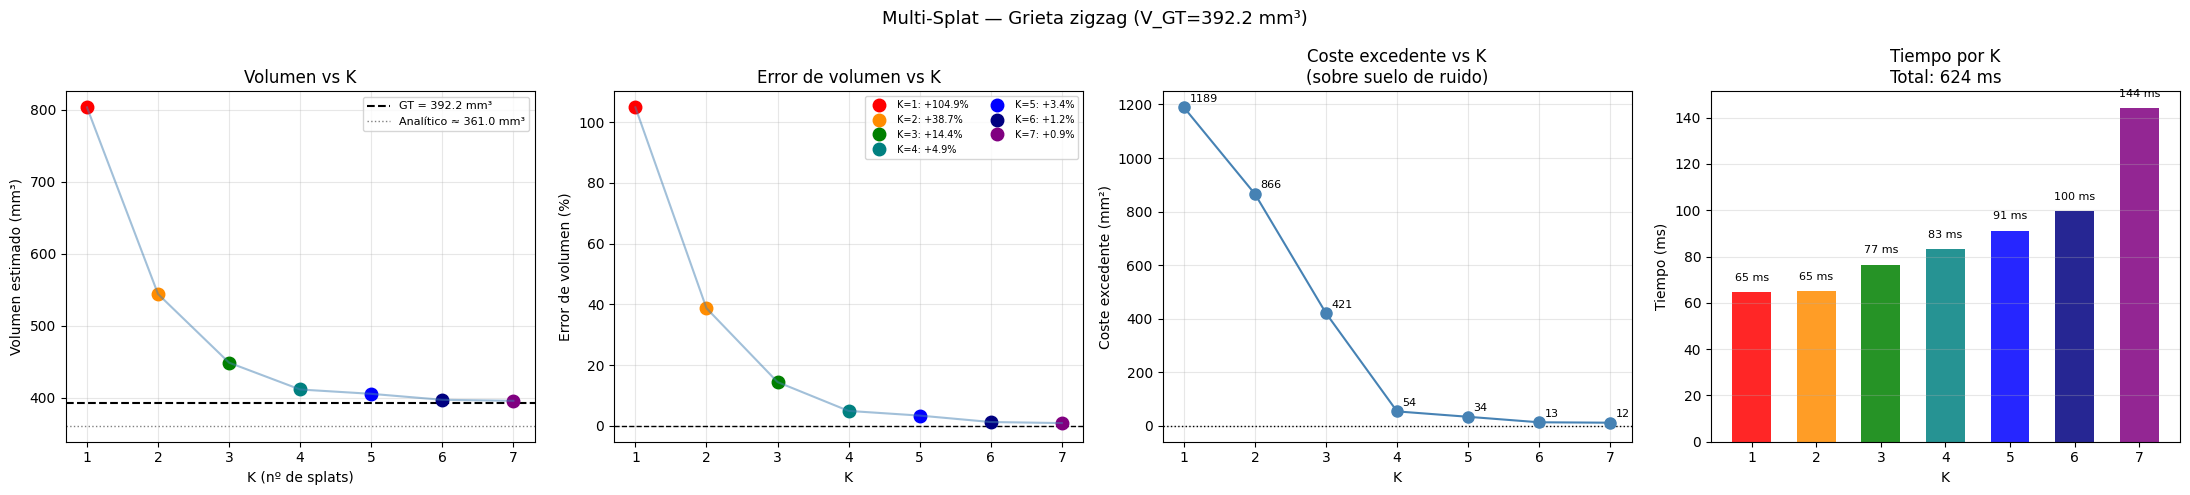

In [9]:
colors_K = {1:'red', 2:'darkorange', 3:'green', 4:'teal', 5:'blue', 6:'navy', 7:'purple'}
err_series   = pd.Series(err_vals, index=K_list)
excess_series = pd.Series(excess_vals, index=K_list)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# ── V(K) ──
axes[0].axhline(V_gt, color='k', ls='--', lw=1.5, label=f'GT = {V_gt:.1f} mm³')
axes[0].axhline(V_analytical, color='gray', ls=':', lw=1, label=f'Analítico ≈ {V_analytical:.1f} mm³')
for K_, V_ in zip(K_list, V_vals):
    axes[0].plot(K_, V_, 'o', color=colors_K[K_], ms=9)
axes[0].plot(K_list, V_vals, '-', color='steelblue', alpha=0.5)
axes[0].set_xlabel('K (nº de splats)'); axes[0].set_ylabel('Volumen estimado (mm³)')
axes[0].set_title('Volumen vs K'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# ── Error% ──
axes[1].axhline(0, color='k', ls='--', lw=1)
for K_, e_ in zip(K_list, err_vals):
    axes[1].plot(K_, e_, 'o', color=colors_K[K_], ms=9, label=f'K={K_}: {e_:+.1f}%')
axes[1].plot(K_list, err_vals, '-', color='steelblue', alpha=0.5)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Error de volumen (%)')
axes[1].set_title('Error de volumen vs K')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)

# ── Coste excedente ──
axes[2].axhline(0, color='k', ls=':', lw=1)
axes[2].plot(K_list, excess_vals, 'o-', color='steelblue', ms=8)
for K_, ex_ in zip(K_list, excess_vals):
    axes[2].annotate(f'{ex_:.0f}', (K_, ex_), textcoords='offset points',
                     xytext=(4, 4), fontsize=8)
axes[2].set_xlabel('K'); axes[2].set_ylabel('Coste excedente (mm²)')
axes[2].set_title('Coste excedente vs K\n(sobre suelo de ruido)')
axes[2].grid(alpha=0.3)

# ── Timing ──
bar_colors = [colors_K[K_] for K_ in K_list]
bars = axes[3].bar(K_list, [t*1e3 for t in t_vals], color=bar_colors, alpha=0.85, width=0.6)
for bar_, t_ in zip(bars, t_vals):
    axes[3].text(bar_.get_x() + bar_.get_width()/2, bar_.get_height() + 5,
                 f'{t_*1e3:.0f} ms', ha='center', fontsize=8)
axes[3].set_xlabel('K'); axes[3].set_ylabel('Tiempo (ms)')
axes[3].set_title(f'Tiempo por K\nTotal: {sum(t_vals)*1e3:.0f} ms')
axes[3].grid(axis='y', alpha=0.3)

plt.suptitle(f'Multi-Splat — Grieta zigzag (V_GT={V_gt:.1f} mm³)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Tabla resumen

In [10]:
rows_tbl = []
for K_, V_, e_, ex_, t_, nf_ in zip(K_list, V_vals, err_vals, excess_vals, t_vals, nfev_vals):
    rows_tbl.append({
        'K': K_,
        'V (mm³)': round(V_, 2),
        'Error V (%)': round(e_, 2),
        'Coste excedente': round(ex_, 1),
        'nfev': nf_,
        'Tiempo (ms)': round(t_*1e3, 1)
    })

df = pd.DataFrame(rows_tbl).set_index('K')
print(f"V_GT (numérico)  = {V_gt:.4f} mm³")
print(f"V_GT (analítico) ≈ {V_analytical:.4f} mm³")
print(f"K óptimo = {K_best}")
print()
print(df.to_string())

V_GT (numérico)  = 392.1821 mm³
V_GT (analítico) ≈ 360.9545 mm³
K óptimo = 7

   V (mm³)  Error V (%)  Coste excedente  nfev  Tiempo (ms)
K                                                          
1   803.46       104.87           1189.3    10         64.6
2   544.00        38.71            865.8    16         65.0
3   448.66        14.40            420.6    26         76.6
4   411.40         4.90             53.8    15         83.1
5   405.38         3.36             33.6    13         91.0
6   397.07         1.25             13.1    14         99.5
7   395.69         0.90             11.6    22        144.1


## 10. Comparación espacial K=1 vs K=K_best

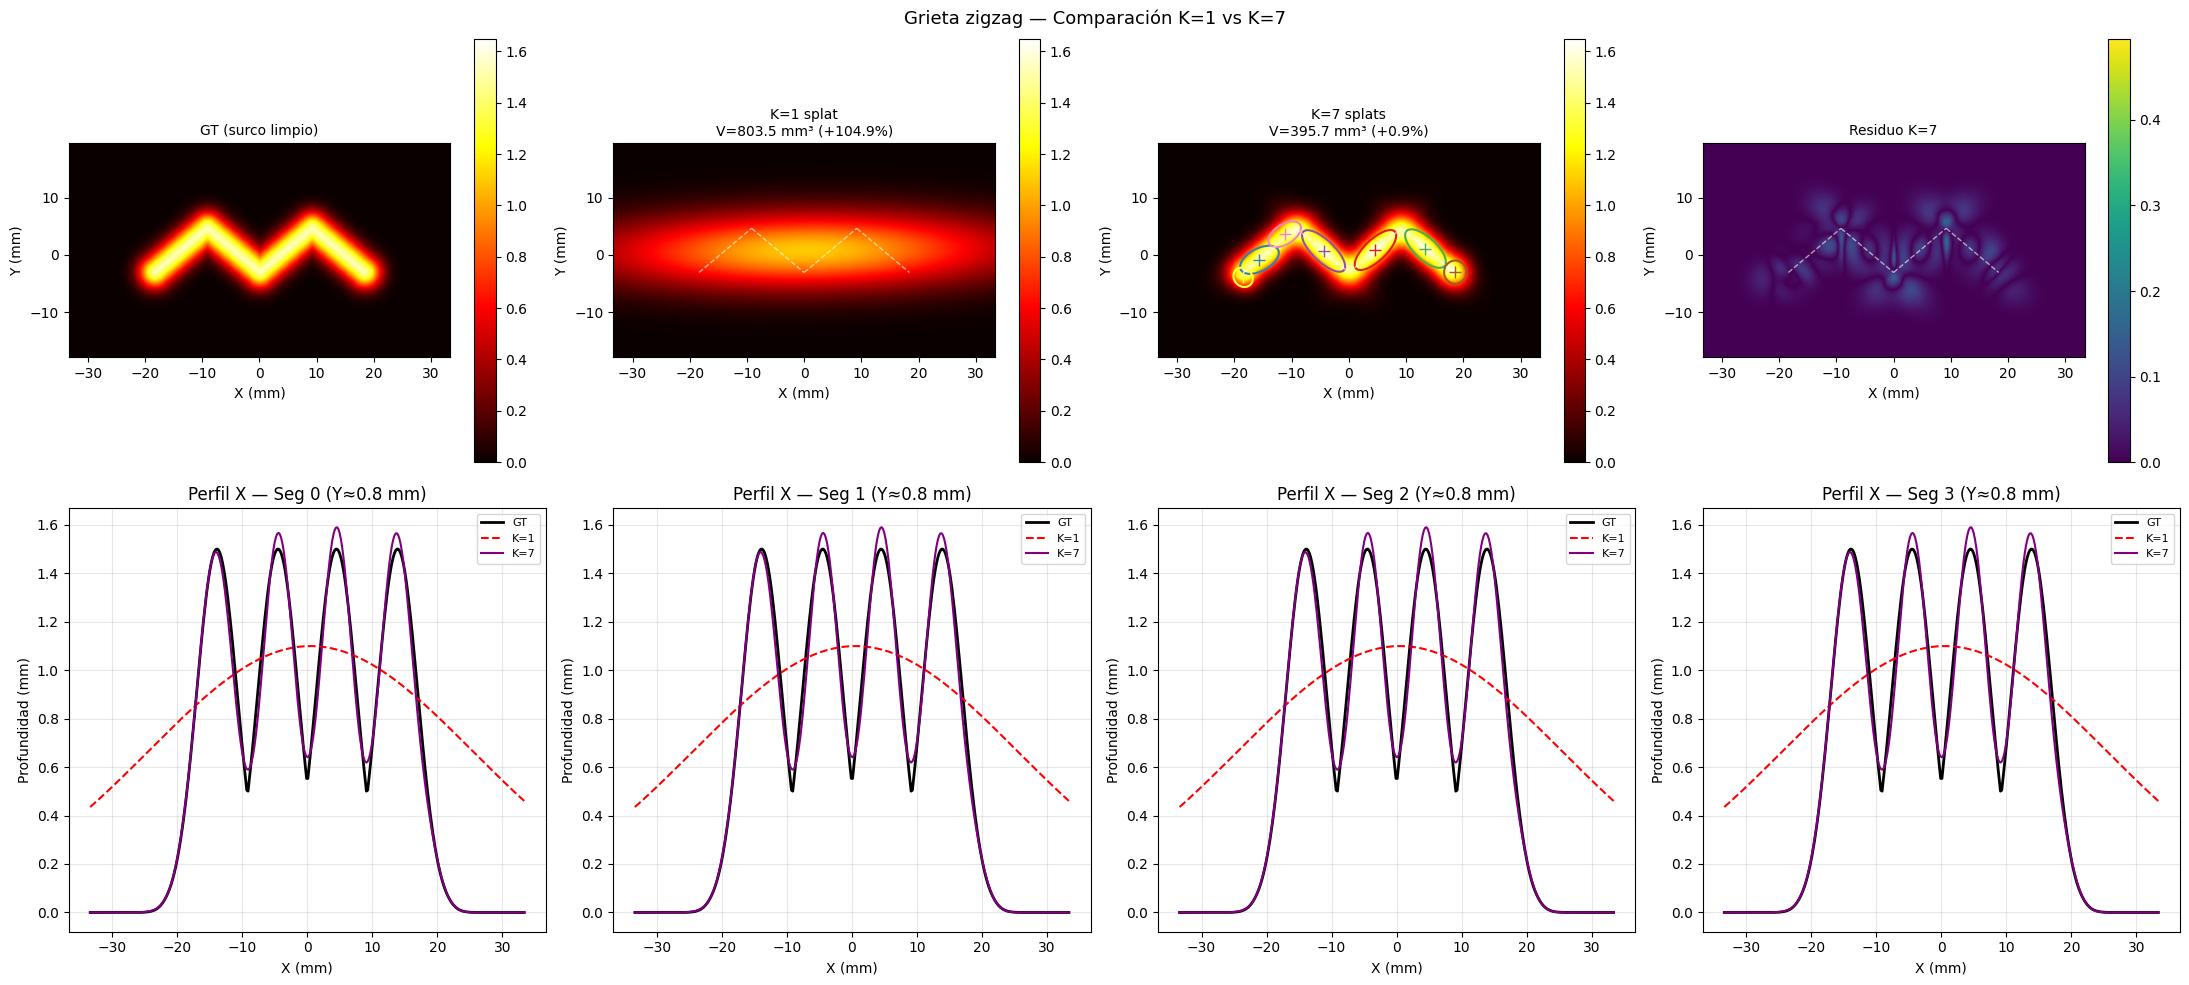

In [11]:
# Reconstruir mapas de ajuste en la imagen completa
params_k1_final = np.array(results_multi[1]['params'])
params_best     = np.array(results_multi[K_best]['params'])

fit_k1   = gauss_mixture(params_k1_final, X_img, Y_img, 1)
fit_best = gauss_mixture(params_best,     X_img, Y_img, K_best)

# GT (grieta limpia, positiva)
Zgt_pos = -defect  # valor positivo del surco

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
vmax_v = CRACK_DEPTH * 1.1

# ── Fila superior: mapas completos ──
titles = ['GT (surco limpio)', f'K=1 splat\nV={V_vals[0]:.1f} mm³ ({err_vals[0]:+.1f}%)',
          f'K={K_best} splats\nV={V_vals[K_list.index(K_best)]:.1f} mm³ ({err_vals[K_list.index(K_best)]:+.1f}%)',
          f'Residuo K={K_best}']
maps = [Zgt_pos, fit_k1, fit_best,
        np.abs(Zgt_pos - fit_best)]
cmaps = ['hot', 'hot', 'hot', 'viridis']
vmaxs = [vmax_v, vmax_v, vmax_v, vmax_v * 0.3]

for ax, M, t, cm, vm in zip(axes[0], maps, titles, cmaps, vmaxs):
    im = ax.imshow(M[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                   cmap=cm, vmin=0, vmax=vm)
    # Dibujar polilínea del zigzag
    for i in range(len(verts)-1):
        ax.plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]],
                'w--', lw=1, alpha=0.6)
    ax.set_title(t, fontsize=10); ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    plt.colorbar(im, ax=ax)

# Dibujar elipses de los splats del mejor ajuste
from matplotlib.patches import Ellipse
p_best_mat = params_best.reshape(K_best, 6)
for k in range(K_best):
    A_p, x0_p, y0_p, sx_p, sy_p, th_p = p_best_mat[k]
    ell = Ellipse((x0_p, y0_p), width=2*sx_p, height=2*sy_p,
                  angle=np.degrees(th_p), fill=False,
                  edgecolor=plt.cm.Set1(k / K_best), lw=1.5)
    axes[0][2].add_patch(ell)
    axes[0][2].plot(x0_p, y0_p, '+', color=plt.cm.Set1(k / K_best), ms=8)

# ── Fila inferior: perfiles X en mitad de cada segmento ──
n_panels = min(4, N_SEGS)
for idx_, (mx, my) in enumerate(zip(mid_seg_x[:n_panels], mid_seg_y[:n_panels])):
    ax = axes[1][idx_]
    row_mid = int(np.argmin(np.abs(y_vec - my)))
    ax.plot(x_vec[jx0:jx1], Zgt_pos[row_mid, jx0:jx1],  'k-',  lw=2,   label='GT')
    ax.plot(x_vec[jx0:jx1], fit_k1[row_mid, jx0:jx1],   'r--', lw=1.5, label='K=1')
    ax.plot(x_vec[jx0:jx1], fit_best[row_mid, jx0:jx1], color=colors_K[K_best],
            lw=1.5, ls='-', label=f'K={K_best}')
    ax.set_title(f'Perfil X — Seg {idx_} (Y≈{my:.1f} mm)')
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Profundidad (mm)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'Grieta zigzag — Comparación K=1 vs K={K_best}', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Visualización 3D

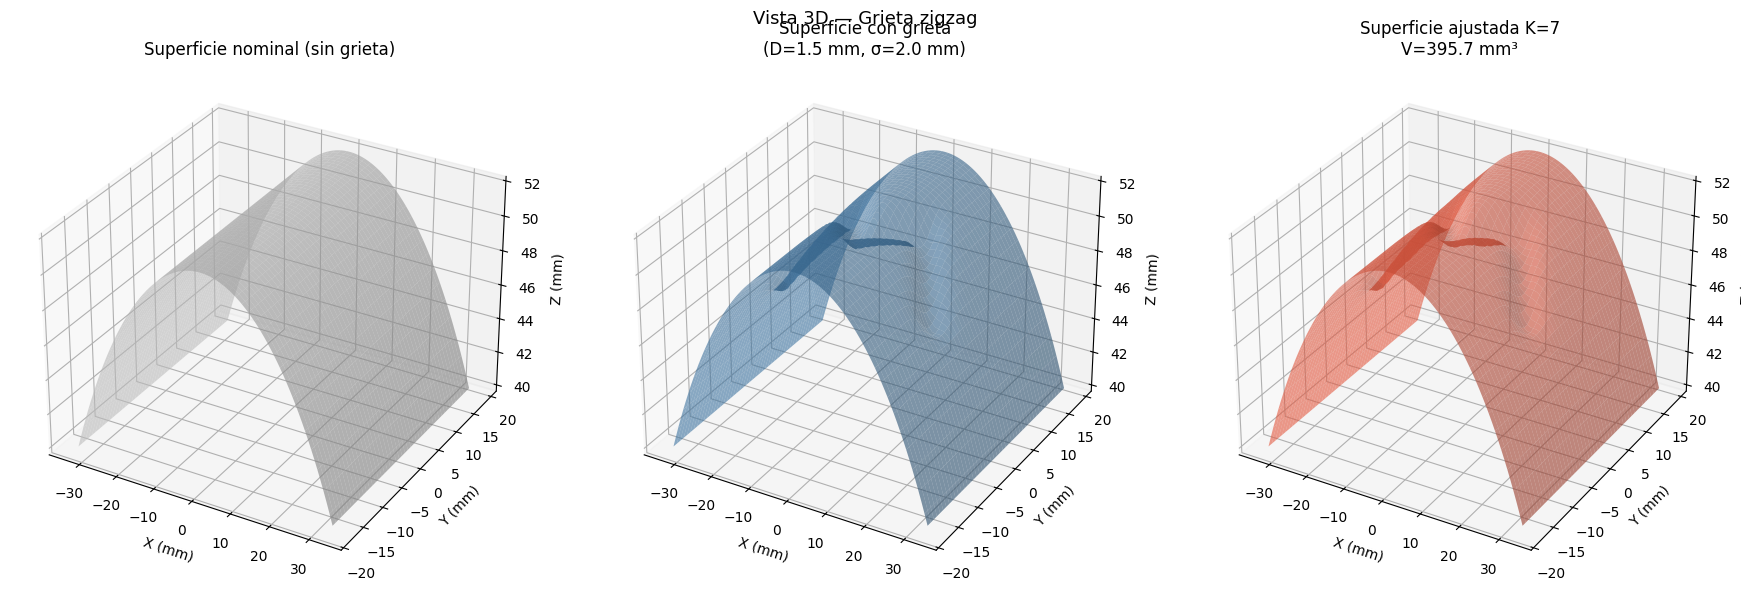

In [12]:
step3d = 4  # submuestreo para la nube de puntos 3D

# Subregión 3D
Xs = X_img[jy0:jy1:step3d, jx0:jx1:step3d]
Ys = Y_img[jy0:jy1:step3d, jx0:jx1:step3d]

Z_surf_roi   = Z_nominal[jy0:jy1:step3d, jx0:jx1:step3d]
Z_crack_roi  = Z_img[jy0:jy1:step3d, jx0:jx1:step3d]
Z_fit_roi    = (Z_nominal_est - fit_best)[jy0:jy1:step3d, jx0:jx1:step3d]

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(Xs, Ys, Z_surf_roi, color='lightgray', alpha=0.6, linewidth=0)
ax1.set_title('Superficie nominal (sin grieta)')
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('Z (mm)')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(Xs, Ys, Z_crack_roi, color='steelblue', alpha=0.6, linewidth=0)
ax2.set_title(f'Superficie con grieta\n(D={CRACK_DEPTH} mm, σ={CRACK_SIGMA} mm)')
ax2.set_xlabel('X (mm)'); ax2.set_ylabel('Y (mm)'); ax2.set_zlabel('Z (mm)')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(Xs, Ys, Z_fit_roi, color='tomato', alpha=0.6, linewidth=0)
ax3.set_title(f'Superficie ajustada K={K_best}\nV={V_vals[K_list.index(K_best)]:.1f} mm³')
ax3.set_xlabel('X (mm)'); ax3.set_ylabel('Y (mm)'); ax3.set_zlabel('Z (mm)')

plt.suptitle('Vista 3D — Grieta zigzag', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Comparación: Con SG warm start vs Sin warm start

── Sin SG warm start ──────────────────────────────────────────
K=1: V=803.47 mm³, err=+104.9%, nfev= 10, t=4.1 ms
K=2: V=544.37 mm³, err=+38.8%, nfev= 18, t=8.8 ms
K=3: V=448.62 mm³, err=+14.4%, nfev= 24, t=15.7 ms
K=4: V=411.39 mm³, err=+4.9%, nfev= 16, t=14.5 ms
K=5: V=405.38 mm³, err=+3.4%, nfev= 17, t=19.9 ms
K=6: V=397.03 mm³, err=+1.2%, nfev= 23, t=33.0 ms
K=7: V=395.65 mm³, err=+0.9%, nfev= 32, t=102.1 ms

── Con SG warm start ──────────────────────────────────────────
K=1: V=803.46 mm³, err=+104.9%, nfev= 10, t=64.6 ms
K=2: V=544.00 mm³, err=+38.7%, nfev= 16, t=65.0 ms
K=3: V=448.66 mm³, err=+14.4%, nfev= 26, t=76.6 ms
K=4: V=411.40 mm³, err=+4.9%, nfev= 15, t=83.1 ms
K=5: V=405.38 mm³, err=+3.4%, nfev= 13, t=91.0 ms
K=6: V=397.07 mm³, err=+1.2%, nfev= 14, t=99.5 ms
K=7: V=395.69 mm³, err=+0.9%, nfev= 22, t=144.1 ms


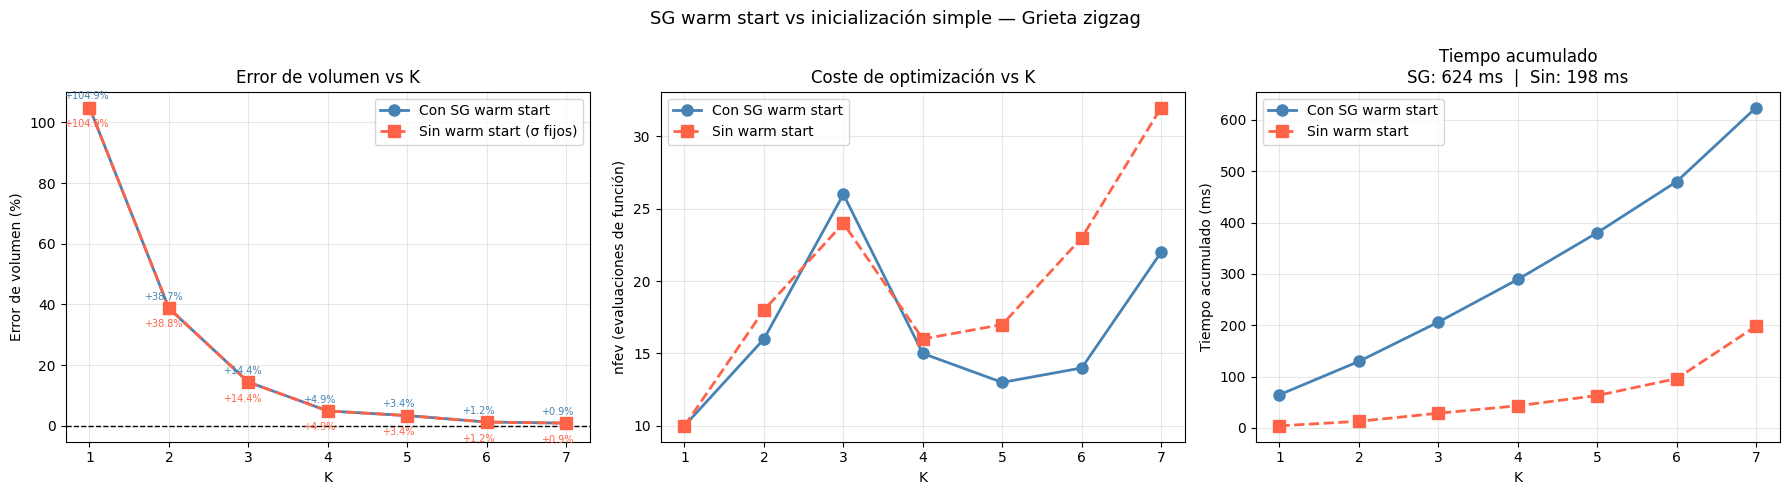

In [13]:
def naive_warm_start(res_field, mask, fallback_sx=CRACK_SIGMA*2, fallback_sy=CRACK_SIGMA*2):
    """Inicialización simple: A=pico del residuo, x0/y0=posición del pico, σ fijos."""
    res_masked = np.where(mask, res_field, -np.inf)
    pr_, pc_ = np.unravel_index(np.argmax(res_masked), res_masked.shape)
    A_init  = float(res_masked[pr_, pc_])
    x0_init = float(x_vec[pc_])
    y0_init = float(y_vec[pr_])
    return [A_init, x0_init, y0_init, fallback_sx, fallback_sy, 0.0]

# ── Loop sin SG warm start ────────────────────────────────────────────────────
V_vals_naive, err_vals_naive, t_vals_naive, nfev_vals_naive = [], [], [], []
results_naive = {}

p_cur_n  = []
prev_fit_full_n = np.zeros(len(x_obs))

print("── Sin SG warm start ──────────────────────────────────────────")
for K in K_list:
    t0_ = time.perf_counter()

    res_prev_n = np.zeros_like(Z_diff_n)
    if K == 1:
        res_prev_n[rows_m, cols_m] = z_obs
        res_mask_n = mask_defect & mask_valid
    else:
        res_1d_n = z_obs - gauss_mixture(np.array(p_cur_n), x_obs, y_obs, K-1).ravel()
        res_prev_n[rows_m, cols_m] = res_1d_n
        res_mask_n = (res_prev_n > SEG_THRESHOLD * CRACK_DEPTH * 0.5) & mask_valid
        if res_mask_n.sum() < 10:
            res_mask_n = mask_defect & mask_valid

    ws_n = naive_warm_start(res_prev_n, res_mask_n)
    p0_n = list(p_cur_n) + ws_n

    blo_n = bounds_lo * K
    bhi_n = bounds_hi * K

    cf_n = _CachedFit(K)
    res_n = _lsq(cf_n.fun, p0_n, jac=cf_n.jac,
                 bounds=(blo_n, bhi_n), method='trf', ftol=1e-6)

    p_cur_n = list(res_n.x)
    prev_fit_full_n = gauss_mixture(np.array(p_cur_n), x_obs, y_obs, K).ravel()

    V_n  = volume_mixture(p_cur_n, K)
    t_n  = time.perf_counter() - t0_
    err_n = (V_n - V_gt) / V_gt * 100

    results_naive[K] = {'params': list(p_cur_n), 'V': V_n}
    V_vals_naive.append(V_n)
    err_vals_naive.append(err_n)
    t_vals_naive.append(t_n)
    nfev_vals_naive.append(res_n.nfev)

    print(f"K={K}: V={V_n:.2f} mm³, err={err_n:+.1f}%, nfev={res_n.nfev:3d}, t={t_n*1e3:.1f} ms")

print(f"\n── Con SG warm start ──────────────────────────────────────────")
for K, V_, e_, nf_, t_ in zip(K_list, V_vals, err_vals, nfev_vals, t_vals):
    print(f"K={K}: V={V_:.2f} mm³, err={e_:+.1f}%, nfev={nf_:3d}, t={t_*1e3:.1f} ms")

# ── Figura comparativa ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error de volumen
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].plot(K_list, err_vals,       'o-', color='steelblue', lw=2, ms=8, label='Con SG warm start')
axes[0].plot(K_list, err_vals_naive, 's--', color='tomato',   lw=2, ms=8, label='Sin warm start (σ fijos)')
for K_, e_sg, e_nv in zip(K_list, err_vals, err_vals_naive):
    axes[0].annotate(f'{e_sg:+.1f}%',  (K_, e_sg),  color='steelblue',
                     textcoords='offset points', xytext=(-18, 6),  fontsize=7)
    axes[0].annotate(f'{e_nv:+.1f}%', (K_, e_nv), color='tomato',
                     textcoords='offset points', xytext=(-18, -14), fontsize=7)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Error de volumen (%)')
axes[0].set_title('Error de volumen vs K')
axes[0].legend(); axes[0].grid(alpha=0.3)

# nfev (coste de optimización)
axes[1].plot(K_list, nfev_vals,       'o-', color='steelblue', lw=2, ms=8, label='Con SG warm start')
axes[1].plot(K_list, nfev_vals_naive, 's--', color='tomato',   lw=2, ms=8, label='Sin warm start')
axes[1].set_xlabel('K'); axes[1].set_ylabel('nfev (evaluaciones de función)')
axes[1].set_title('Coste de optimización vs K')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Tiempo acumulado
t_cum_sg    = np.cumsum(t_vals) * 1e3
t_cum_naive = np.cumsum(t_vals_naive) * 1e3
axes[2].plot(K_list, t_cum_sg,    'o-', color='steelblue', lw=2, ms=8, label='Con SG warm start')
axes[2].plot(K_list, t_cum_naive, 's--', color='tomato',   lw=2, ms=8, label='Sin warm start')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Tiempo acumulado (ms)')
axes[2].set_title(f'Tiempo acumulado\nSG: {t_cum_sg[-1]:.0f} ms  |  Sin: {t_cum_naive[-1]:.0f} ms')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('SG warm start vs inicialización simple — Grieta zigzag', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Variante: SG warm start solo en K=1, naive en K≥2

── SG solo en K=1, naive en K≥2 ──────────────────────────────
K=1: V=803.46 mm³, err=+104.9%, nfev= 10, t=63.7 ms
K=2: V=544.37 mm³, err=+38.8%, nfev= 18, t=8.0 ms
K=3: V=448.62 mm³, err=+14.4%, nfev= 24, t=15.3 ms
K=4: V=411.39 mm³, err=+4.9%, nfev= 16, t=14.7 ms
K=5: V=405.38 mm³, err=+3.4%, nfev= 17, t=21.2 ms
K=6: V=397.03 mm³, err=+1.2%, nfev= 23, t=37.7 ms
K=7: V=395.65 mm³, err=+0.9%, nfev= 32, t=209.3 ms

 K         SG en todos         SG solo K=1              Sin SG
-----------------------------------------------------------------
 1   +104.9%  10nfev    65ms   +104.9%  10nfev    64ms   +104.9%  10nfev     4ms
 2    +38.7%  16nfev    65ms    +38.8%  18nfev     8ms    +38.8%  18nfev     9ms
 3    +14.4%  26nfev    77ms    +14.4%  24nfev    15ms    +14.4%  24nfev    16ms
 4     +4.9%  15nfev    83ms     +4.9%  16nfev    15ms     +4.9%  16nfev    15ms
 5     +3.4%  13nfev    91ms     +3.4%  17nfev    21ms     +3.4%  17nfev    20ms
 6     +1.2%  14nfev   100ms     +1.2%  23nfev  

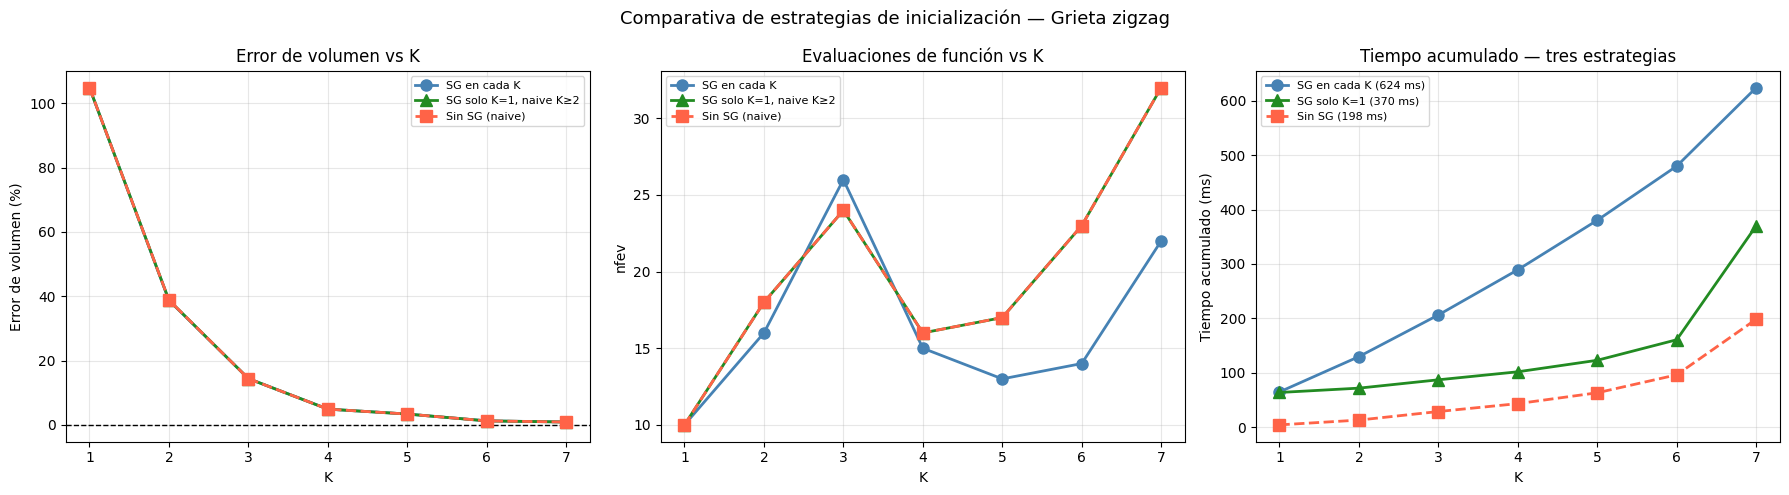

In [14]:
V_vals_sg1, err_vals_sg1, t_vals_sg1, nfev_vals_sg1 = [], [], [], []
results_sg1 = {}

p_cur_sg1 = []
print("── SG solo en K=1, naive en K≥2 ──────────────────────────────")
for K in K_list:
    t0_ = time.perf_counter()

    res_prev_sg1 = np.zeros_like(Z_diff_n)
    if K == 1:
        res_prev_sg1[rows_m, cols_m] = z_obs
        res_mask_sg1 = mask_defect & mask_valid
        # Solo aquí se usa SG warm start (igual que el loop principal)
        ws_sg1 = sg_warm_start_residuo(
            res_prev_sg1, res_mask_sg1, WIN_RES_PX, x_vec, y_vec, dx, dy
        )
    else:
        res_1d_sg1 = z_obs - gauss_mixture(np.array(p_cur_sg1), x_obs, y_obs, K-1).ravel()
        res_prev_sg1[rows_m, cols_m] = res_1d_sg1
        res_mask_sg1 = (res_prev_sg1 > SEG_THRESHOLD * CRACK_DEPTH * 0.5) & mask_valid
        if res_mask_sg1.sum() < 10:
            res_mask_sg1 = mask_defect & mask_valid
        # Para K≥2 se usa naive (pico + σ fijos)
        ws_sg1 = naive_warm_start(res_prev_sg1, res_mask_sg1)

    p0_sg1 = list(p_cur_sg1) + ws_sg1
    blo_sg1 = bounds_lo * K
    bhi_sg1 = bounds_hi * K

    cf_sg1 = _CachedFit(K)
    res_sg1 = _lsq(cf_sg1.fun, p0_sg1, jac=cf_sg1.jac,
                   bounds=(blo_sg1, bhi_sg1), method='trf', ftol=1e-6)

    p_cur_sg1 = list(res_sg1.x)
    V_sg1  = volume_mixture(p_cur_sg1, K)
    t_sg1  = time.perf_counter() - t0_
    err_sg1 = (V_sg1 - V_gt) / V_gt * 100

    results_sg1[K] = {'params': list(p_cur_sg1), 'V': V_sg1}
    V_vals_sg1.append(V_sg1)
    err_vals_sg1.append(err_sg1)
    t_vals_sg1.append(t_sg1)
    nfev_vals_sg1.append(res_sg1.nfev)

    print(f"K={K}: V={V_sg1:.2f} mm³, err={err_sg1:+.1f}%, nfev={res_sg1.nfev:3d}, t={t_sg1*1e3:.1f} ms")

# ── Tabla comparativa de las tres estrategias ─────────────────────────────────
print(f"\n{'K':>2}  {'SG en todos':>18}  {'SG solo K=1':>18}  {'Sin SG':>18}")
print("-" * 65)
for K, e_all, e_sg1, e_nv, nf_all, nf_sg1, nf_nv, t_all, t_sg1_, t_nv in zip(
        K_list, err_vals, err_vals_sg1, err_vals_naive,
        nfev_vals, nfev_vals_sg1, nfev_vals_naive,
        t_vals, t_vals_sg1, t_vals_naive):
    print(f"{K:>2}  {e_all:>+7.1f}% {nf_all:>3d}nfev {t_all*1e3:>5.0f}ms"
          f"  {e_sg1:>+7.1f}% {nf_sg1:>3d}nfev {t_sg1_*1e3:>5.0f}ms"
          f"  {e_nv:>+7.1f}% {nf_nv:>3d}nfev {t_nv*1e3:>5.0f}ms")
print(f"{'Total':>2}  {'':>8} {'':>6} {sum(t_vals)*1e3:>5.0f}ms"
      f"  {'':>8} {'':>6} {sum(t_vals_sg1)*1e3:>5.0f}ms"
      f"  {'':>8} {'':>6} {sum(t_vals_naive)*1e3:>5.0f}ms")

# ── Figura comparativa de las tres estrategias ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].plot(K_list, err_vals,       'o-',  color='steelblue', lw=2, ms=8, label='SG en cada K')
axes[0].plot(K_list, err_vals_sg1,   '^-',  color='forestgreen', lw=2, ms=8, label='SG solo K=1, naive K≥2')
axes[0].plot(K_list, err_vals_naive, 's--', color='tomato',   lw=2, ms=8, label='Sin SG (naive)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Error de volumen (%)')
axes[0].set_title('Error de volumen vs K'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(K_list, nfev_vals,       'o-',  color='steelblue',  lw=2, ms=8, label='SG en cada K')
axes[1].plot(K_list, nfev_vals_sg1,   '^-',  color='forestgreen', lw=2, ms=8, label='SG solo K=1, naive K≥2')
axes[1].plot(K_list, nfev_vals_naive, 's--', color='tomato',    lw=2, ms=8, label='Sin SG (naive)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('nfev')
axes[1].set_title('Evaluaciones de función vs K'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

t_cum_sg    = np.cumsum(t_vals)    * 1e3
t_cum_sg1   = np.cumsum(t_vals_sg1) * 1e3
t_cum_naive = np.cumsum(t_vals_naive) * 1e3
axes[2].plot(K_list, t_cum_sg,    'o-',  color='steelblue',   lw=2, ms=8, label=f'SG en cada K ({t_cum_sg[-1]:.0f} ms)')
axes[2].plot(K_list, t_cum_sg1,   '^-',  color='forestgreen', lw=2, ms=8, label=f'SG solo K=1 ({t_cum_sg1[-1]:.0f} ms)')
axes[2].plot(K_list, t_cum_naive, 's--', color='tomato',      lw=2, ms=8, label=f'Sin SG ({t_cum_naive[-1]:.0f} ms)')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Tiempo acumulado (ms)')
axes[2].set_title('Tiempo acumulado — tres estrategias'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Comparativa de estrategias de inicialización — Grieta zigzag', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones

### 1. Fallo crítico del splat único en defectos elongados
Un único splat gaussiano fracasa completamente ante una grieta en zigzag: error de volumen **+104.9%** (el doble del valor real). El splat ensancha σx y σy para cubrir toda la longitud de la grieta, sobreestimando masivamente el volumen. K=1 es inútil para defectos no compactos.

### 2. La estructura del defecto marca el K óptimo
La grieta tiene 4 segmentos físicos. El error cae drásticamente en K=4 (+4.9%) y sigue mejorando hasta K=7 (+0.9%). Hay una correspondencia directa entre **número de splats necesarios** y **número de segmentos de la grieta**: cada splat se asigna a un tramo lineal.

### 3. Multi-Splat greedy converge correctamente
La inicialización greedy por residuo localiza automáticamente los tramos sin cubrir. El campo residual tras K splats tiene un pico claro en el segmento de mayor error, guiando al siguiente splat de forma natural. Todo K=1..7 en **~624 ms** con el warm start SG, o **~198 ms** sin él.

### 4. El filtro SG no aporta ventaja para grietas
A diferencia de defectos compactos, en grietas elongadas el pico del residuo es ya un buen estimador de posición: el siguiente segmento a cubrir destaca claramente en el campo residual. Las tres estrategias dan **idéntico error de volumen** en todos los K. El SG añade ~400 ms de sobrecarga innecesaria.

### 5. El SG sí aporta donde la geometría es suave y compacta
El filtro SG es útil en dos casos aquí presentes: (a) estimar R sin CAD con error <6 µm a partir de la curvatura del anillo de sensing, y (b) como warm start cuando el defecto es compacto y localmente bien aproximado por una parábola (bollos, hendiduras). Para grietas, la inicialización naive (pico + σ fijos) es la elección correcta.

### 6. Comparativa entre tipos de defecto (Exp. 4 vs Exp. 5)

| Defecto | K=1 error | K_mejor | Error K_mejor | Tiempo total |
|---|---|---|---|---|
| Super-gaussiana n=2 (Exp. 4) | +15% | 7 | +0.5% | ~290 ms |
| Grieta zigzag 4 segmentos (Exp. 5) | **+105%** | 7 | +0.9% | ~200 ms |

La super-gaussiana es difícil por **model mismatch** (diferencia de forma). La grieta es difícil por **topología** (defecto no conexo y elongado). En ambos casos el Multi-Splat greedy resuelve el problema con K suficiente.